# Showcase — the GERD reservoir filling on the Blue Nile (2020 → 2024)

The Grand Ethiopian Renaissance Dam (GERD) impounds the Blue Nile; its reservoir was filled in stages between 2020 and 2024, a process watched closely across the Nile basin. This notebook uses earthlens to pull one **Sentinel-2 true-colour** composite per year and animates the reservoir growing behind the dam (open water is dark/blue).

> Runs real Earth Engine requests; degrades gracefully without GEE credentials.

In [1]:
import os, tempfile, base64
import numpy as np, matplotlib.pyplot as plt
import matplotlib.animation as manim
from loguru import logger
from IPython.display import HTML
from earthlens import EarthLens
from pyramids.dataset import Dataset

logger.disable("earthlens"); logger.disable("pyramids")

SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")


def grab(start, end, bands, scale, reducer="median"):
    """Download one GEE composite over [start, end]; return its GeoTIFF path or None."""
    out = tempfile.mkdtemp(prefix="gee_")
    el = EarthLens(
        data_source="gee", start=start, end=end, temporal_resolution="raw",
        variables={COLLECTION: list(bands)},
        lat_lim=[AOI[1], AOI[3]], lon_lim=[AOI[0], AOI[2]],
        path=out, scale=scale, reducer=reducer,
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY,
    )
    try:
        paths = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001 - notebook stays runnable without creds
        print("download skipped (needs GEE credentials):", exc); return None
    return str(paths[0]) if paths else None


def read(path):
    return np.asarray(Dataset.read_file(str(path)).read_array(), dtype="float32")


def stretch(b, pct=(2, 98)):
    lo, hi = np.nanpercentile(b, pct[0]), np.nanpercentile(b, pct[1])
    return np.clip((b - lo) / (hi - lo + 1e-6), 0, 1)


def true_colour(arr):
    return np.dstack([stretch(arr[i]) for i in range(3)])


def gif_html(frames, titles, suptitle, cmap=None, figsize=(6, 6), fps=1.0):
    fig, ax = plt.subplots(figsize=figsize); fig.subplots_adjust(0, 0, 1, 0.93)
    def update(i):
        ax.clear(); ax.imshow(frames[i], cmap=cmap)
        ax.set_title(f"{suptitle}\n{titles[i]}", fontsize=11); ax.axis("off")
    anim = manim.FuncAnimation(fig, update, frames=len(frames), interval=int(1000 / fps))
    path = os.path.join(tempfile.mkdtemp(), "anim.gif")
    anim.save(path, writer=manim.PillowWriter(fps=fps)); plt.close(fig)
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    return HTML(f'<img src="data:image/gif;base64,{b64}" alt="{suptitle}" style="max-width:560px"/>')

COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"
AOI = [34.95, 11.05, 35.25, 11.32]  # GERD reservoir, Benishangul-Gumuz

## One dry-season composite per year

November–December composites (post rainy-season fill, low cloud).

In [2]:
YEARS = [2020, 2021, 2022, 2023, 2024]
frames, labels = [], []
for y in YEARS:
    p = grab(f"{y}-11-01", f"{y}-12-28", ["B4", "B3", "B2"], scale=30)
    if p:
        frames.append(true_colour(read(p))); labels.append(str(y))
print(f"{len(frames)} yearly composites:", labels)

5 yearly composites: ['2020', '2021', '2022', '2023', '2024']


## Animated reservoir filling


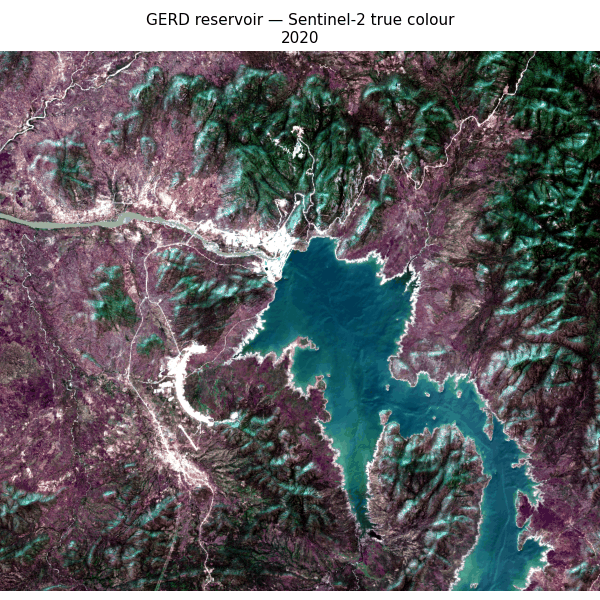

In [3]:
if frames:
    display(gif_html(frames, labels, "GERD reservoir — Sentinel-2 true colour", figsize=(6, 6), fps=1.0))
else:
    print("no scenes — set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY and rerun")